In [1]:
from lib.readwav import readwav
from lib.functions import get_f0_from_peaks, extract_harmonics, get_average_spectrum, get_adaptive_params, find_closest_note, get_f0_from_regression
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
%matplotlib widget
plt.close('all')

(332193, 2)
Frequenza fondamentale stimata: 1563.44 Hz


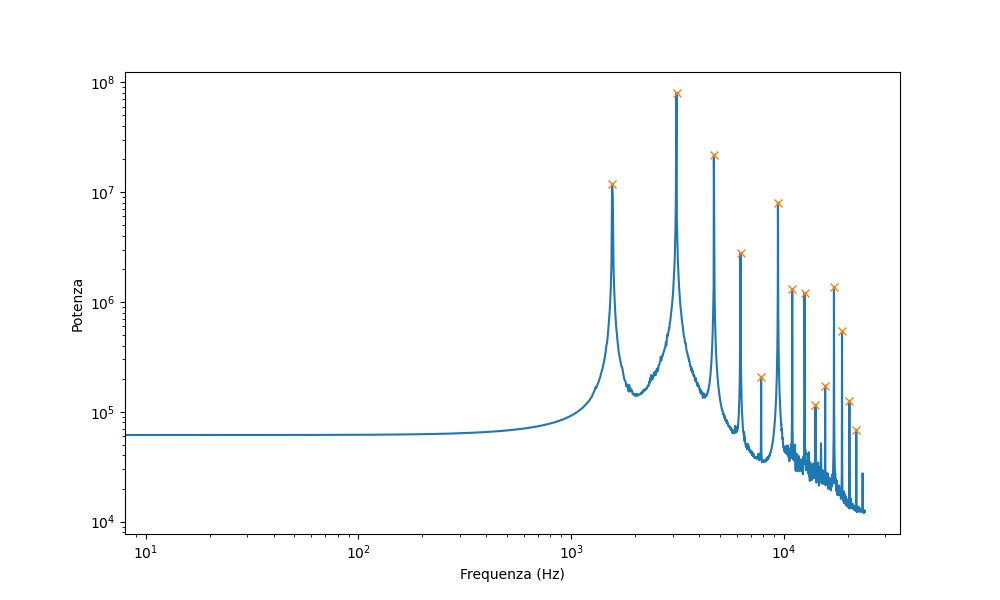

In [3]:
note_data = readwav('Data_organ/note_1.wav')
rate, data = note_data
print(data.shape)
channel1 = data[:,0]
channel2 = data[:,1]

window_size, hop_size = get_adaptive_params(channel1, rate)
freqs, power_spectrum = get_average_spectrum(channel1, rate, window_size, hop_size)

peaks, _ = sp.signal.find_peaks(power_spectrum, prominence=5*1e4)

f0 = get_f0_from_regression(freqs[peaks])
print(f"Frequenza fondamentale stimata: {f0:.2f} Hz")


plt.figure(figsize=(10, 6))
plt.plot(freqs, power_spectrum)
plt.plot(freqs[peaks], power_spectrum[peaks], 'x')
plt.xscale('log')
plt.xlabel('Frequenza (Hz)')
plt.ylabel('Potenza')
plt.yscale('log')
plt.show()

File indices: [1, 31, 61, 91, 121, 151, 181]
File: note_1.wav, X primo bin depresso (alpha=3.0): 5.73e+04
File: note_31.wav, X primo bin depresso (alpha=3.0): 5.59e+05
File: note_61.wav, X primo bin depresso (alpha=3.0): 2.60e+05
File: note_91.wav, X primo bin depresso (alpha=3.0): 1.80e+05
File: note_121.wav, X primo bin depresso (alpha=3.0): 5.98e+05
File: note_151.wav, X primo bin depresso (alpha=3.0): 6.81e+05
File: note_181.wav, X primo bin depresso (alpha=3.0): 6.05e+05


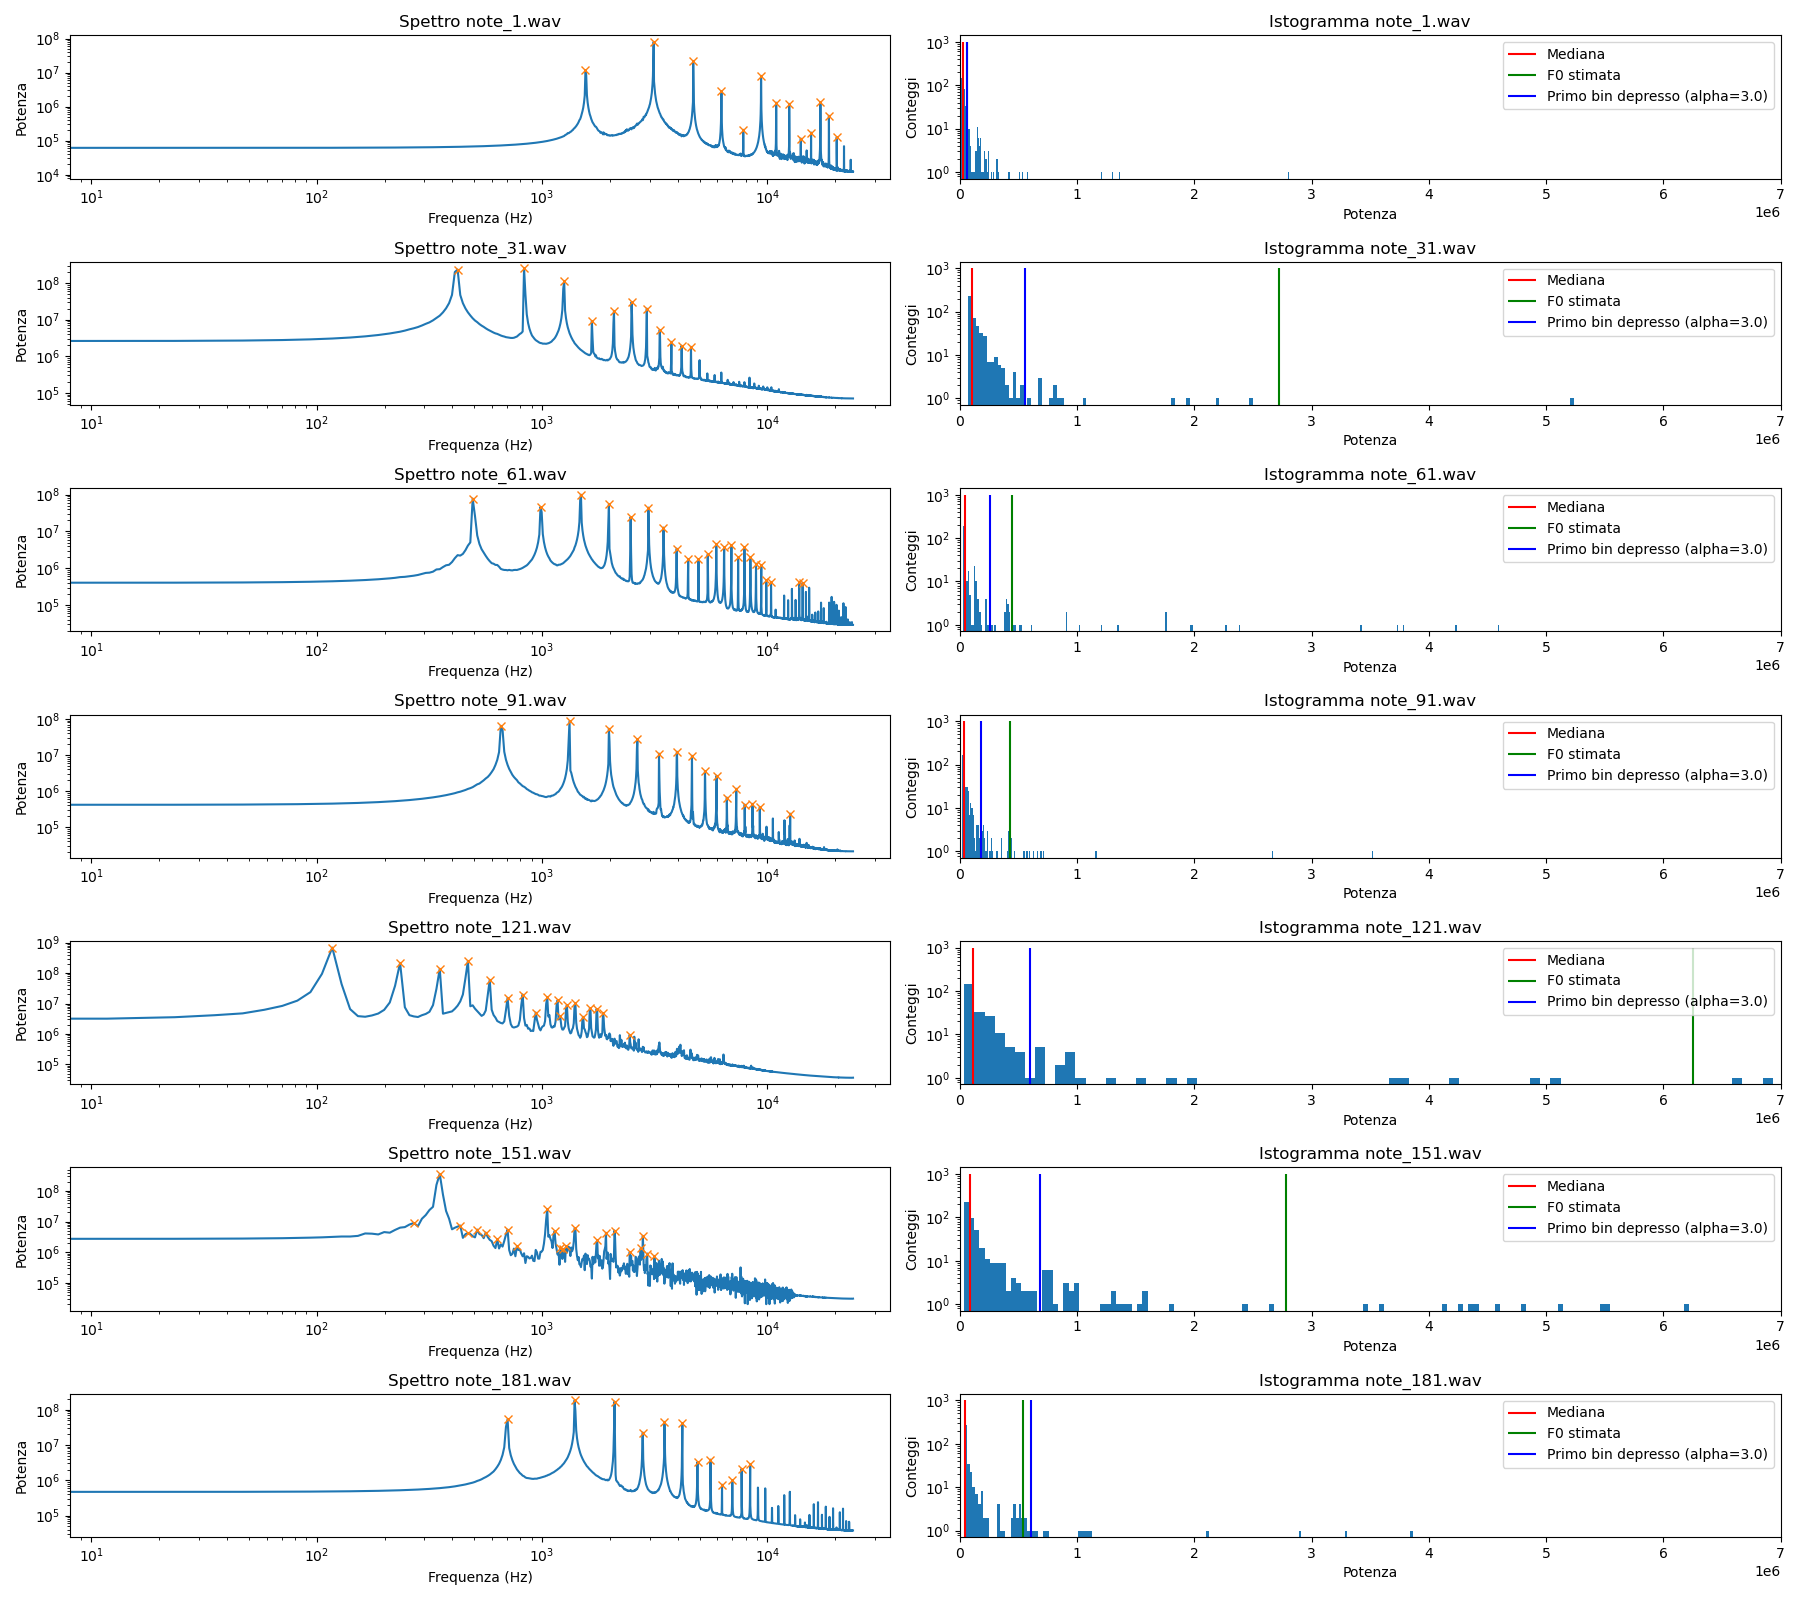

In [12]:
"""peaks_hist, _ = sp.signal.find_peaks(power_spectrum, prominence=1e3)


plt.figure(figsize=(10, 6))
rate, data = note_data
print(data.shape)
channel1 = data[:,0]
channel2 = data[:,1]
"""

file_indices = list(range(1, 200, 30))
print(f"File indices: {file_indices}")  

num_plots = len(file_indices)
alpha = 3.0

#salvataggio x primo bin depresso
x_depre = []

plt.figure(figsize=(18, 16))


for i in file_indices:
    note_data = readwav(f'Data_organ/note_{i}.wav')
    rate, data = note_data
    channel1 = data[:,0]

    window_size, hop_size = get_adaptive_params(channel1, rate)
    freqs, power_spectrum = get_average_spectrum(channel1, rate, window_size, hop_size)
    
    adaptive_prominence = 1e-5 * np.max(power_spectrum)

    peaks_hist, _ = sp.signal.find_peaks(power_spectrum, prominence=1e2)

    peaks_hist_f0, _ = sp.signal.find_peaks(power_spectrum, prominence=adaptive_prominence)

    median_power = np.median(power_spectrum[peaks_hist])

    f0 = round(get_f0_from_regression(freqs[peaks_hist_f0]))
    f0_index = np.argmin(np.abs(freqs - f0))

    row_index = i // 30
    ax_hist = plt.subplot(num_plots, 2, row_index * 2 + 2)
    ax_spectrum = plt.subplot(num_plots, 2, row_index * 2 + 1)

    hist_y, bin_edges = np.histogram(power_spectrum[peaks_hist], bins=8000)
    dip_condition = (hist_y[1:-1] * alpha < hist_y[:-2]) & (hist_y[1:-1] * alpha < hist_y[2:])
    dip_indices = np.where(dip_condition)[0] + 1
    if dip_indices.size > 0:
        first_dip_bin_index = dip_indices[0]
        x_first_dip_bin = 0.5 * (bin_edges[first_dip_bin_index] + bin_edges[first_dip_bin_index + 1])
    else:
        first_dip_bin_index = None
        x_first_dip_bin = np.nan

    ax_hist.hist(power_spectrum[peaks_hist], bins=8000)

    ax_hist.vlines(median_power, 0, 1000, colors='r', label='Mediana')
    ax_hist.vlines(power_spectrum[f0_index], 0, 1000, colors='g', label='F0 stimata')
    if np.isfinite(x_first_dip_bin):
        ax_hist.vlines(x_first_dip_bin, 0, 1000, colors='b', label=f'Primo bin depresso (alpha={alpha})')
    ax_hist.legend()
    ax_hist.set_xlim(0, 7*1e6)
    ax_hist.set_yscale('log')
    ax_hist.set_title(f'Istogramma note_{i}.wav')
    ax_hist.set_xlabel('Potenza')
    ax_hist.set_ylabel('Conteggi')

    prominence_for_peaks = x_first_dip_bin if np.isfinite(x_first_dip_bin) else adaptive_prominence
    peaks_spectrum, _ = sp.signal.find_peaks(power_spectrum, prominence=prominence_for_peaks)

    ax_spectrum.plot(freqs, power_spectrum)
    ax_spectrum.plot(freqs[peaks_spectrum], power_spectrum[peaks_spectrum], 'x')
    ax_spectrum.set_xscale('log')
    ax_spectrum.set_yscale('log')
    ax_spectrum.set_title(f'Spettro note_{i}.wav')
    ax_spectrum.set_xlabel('Frequenza (Hz)')
    ax_spectrum.set_ylabel('Potenza')

    print(f"File: note_{i}.wav, X primo bin depresso (alpha={alpha}): {x_first_dip_bin:.2e}")
    x_depre.append(x_first_dip_bin)

plt.tight_layout()
plt.show()



File: note_1.wav, F0 stimata: 1563.57 Hz
File: note_31.wav, F0 stimata: 415.84 Hz
File: note_61.wav, F0 stimata: 494.82 Hz
File: note_91.wav, F0 stimata: 661.29 Hz
File: note_121.wav, F0 stimata: 117.19 Hz
File: note_151.wav, F0 stimata: 72.16 Hz
File: note_181.wav, F0 stimata: 699.29 Hz


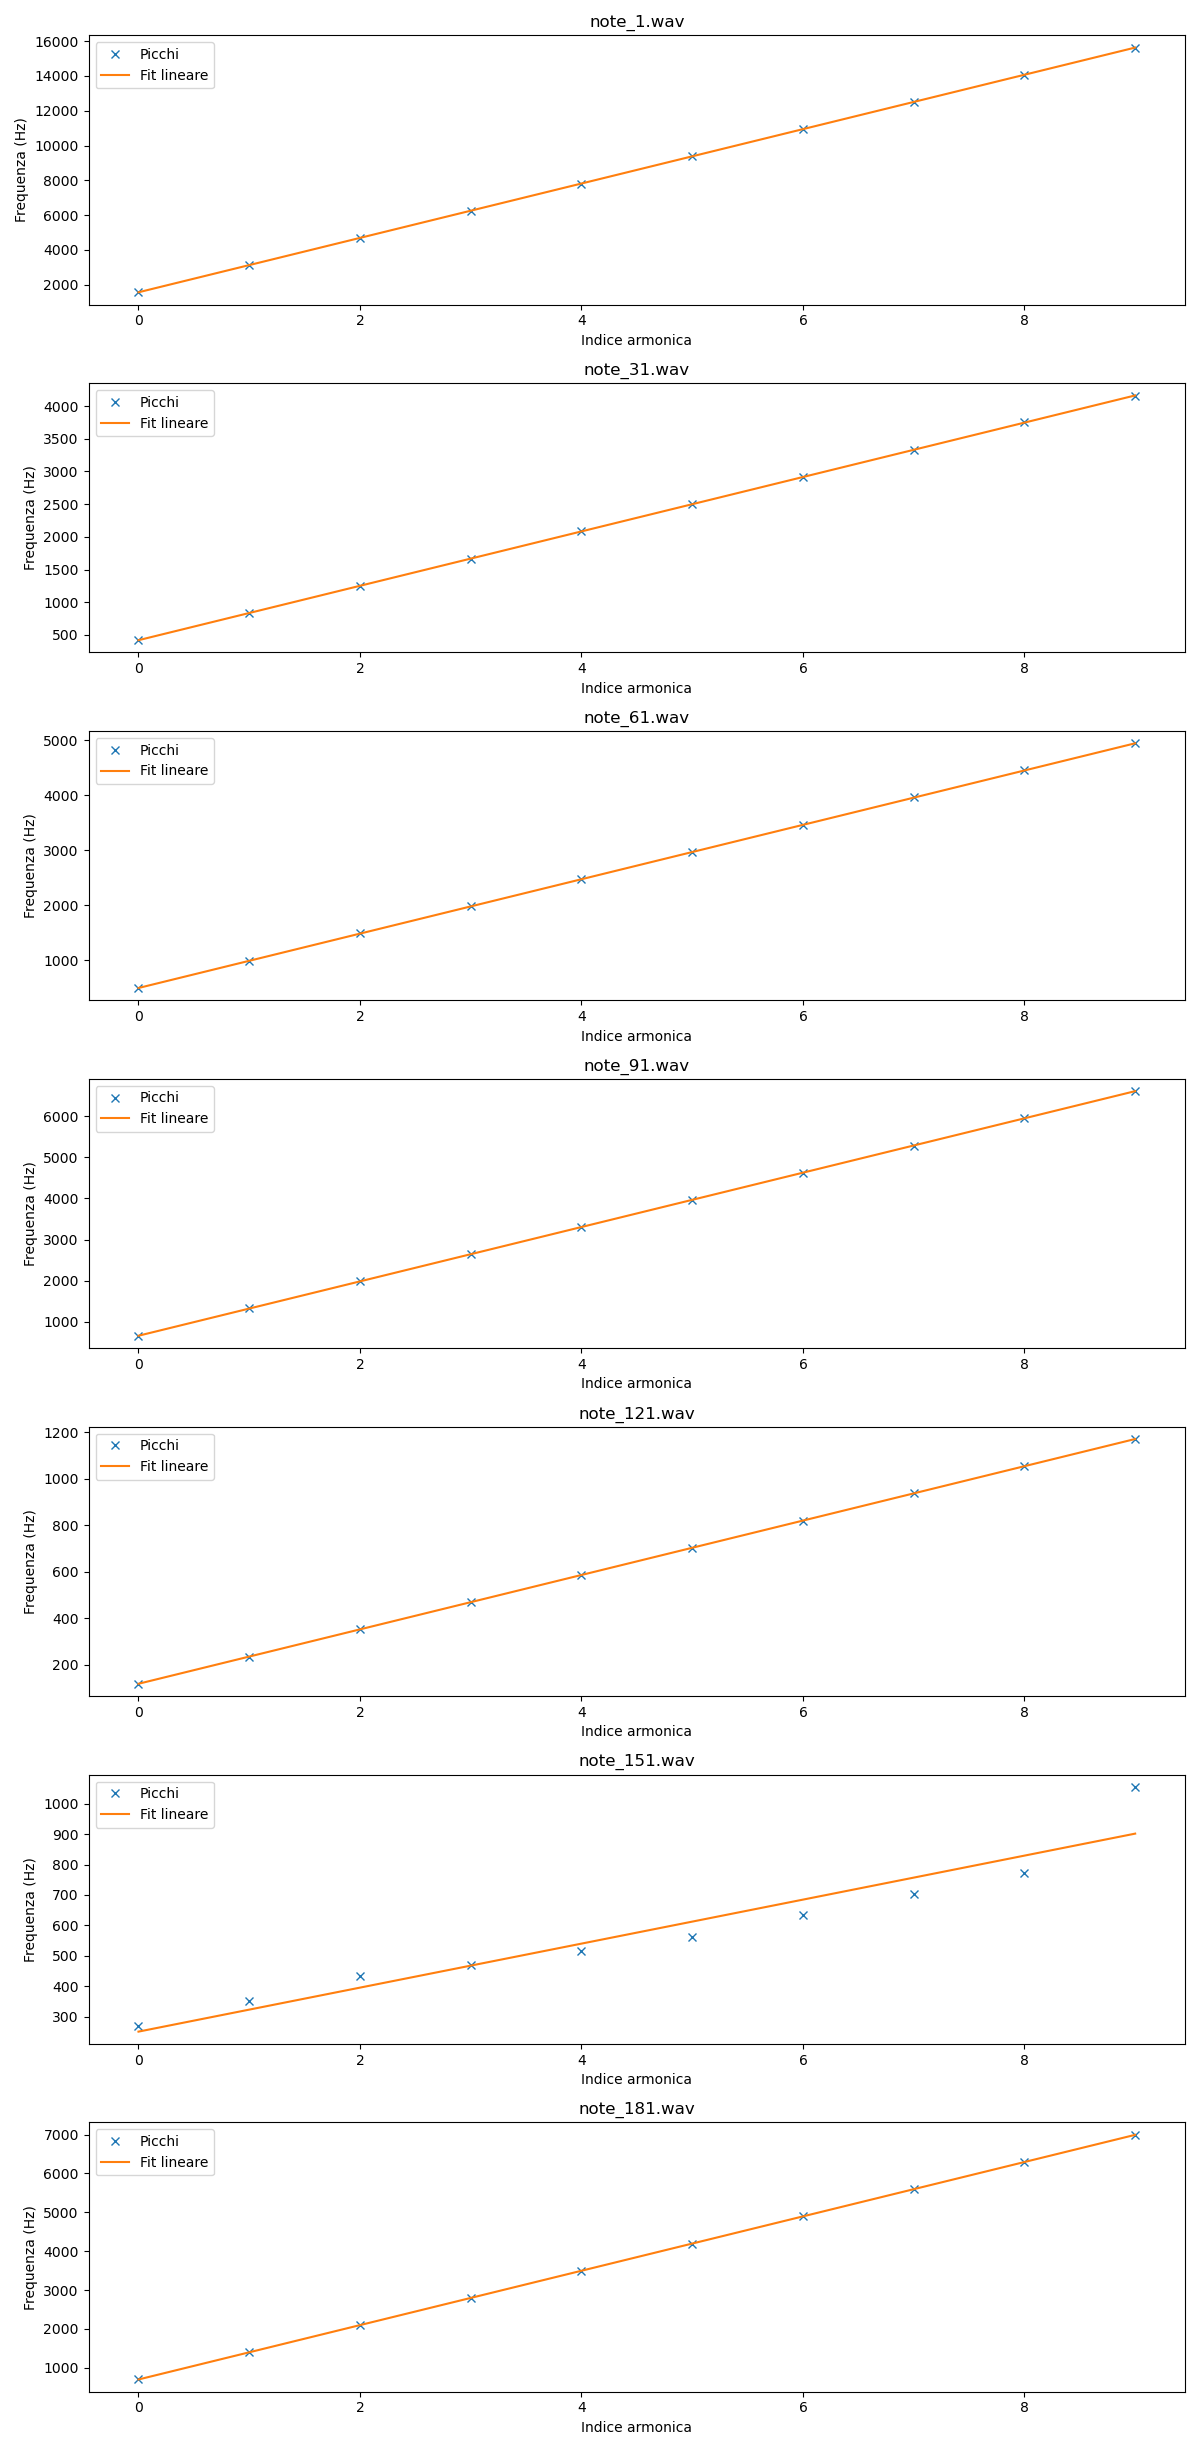

In [14]:
fig, axes = plt.subplots(num_plots, 1, figsize=(12, 3.5 * num_plots))

if num_plots == 1:
    axes = [axes]

for row_index, i in enumerate(file_indices):
    note_data = readwav(f'Data_organ/note_{i}.wav')
    rate, data = note_data
    channel1 = data[:, 0]

    window_size, hop_size = get_adaptive_params(channel1, rate)
    freqs, power_spectrum = get_average_spectrum(channel1, rate, window_size, hop_size)

    prominence_i = x_depre[row_index] 
    peaks, _ = sp.signal.find_peaks(power_spectrum, prominence=prominence_i)
    first_10_peaks = peaks[:10]

    ax = axes[row_index]

    x = np.arange(len(first_10_peaks))
    y = freqs[first_10_peaks]

    coefficients = np.polyfit(x, y, 1)
    f0 = coefficients[0]
    print(f"File: note_{i}.wav, F0 stimata: {f0:.2f} Hz")

    ax.plot(x, y, 'x', label='Picchi')
    ax.plot(x, np.polyval(coefficients, x), label='Fit lineare')
    ax.set_title(f'note_{i}.wav')
    ax.set_xlabel('Indice armonica')
    ax.set_ylabel('Frequenza (Hz)')
    ax.legend()

plt.tight_layout()
plt.show()

F0 stimata: 699.29 Hz


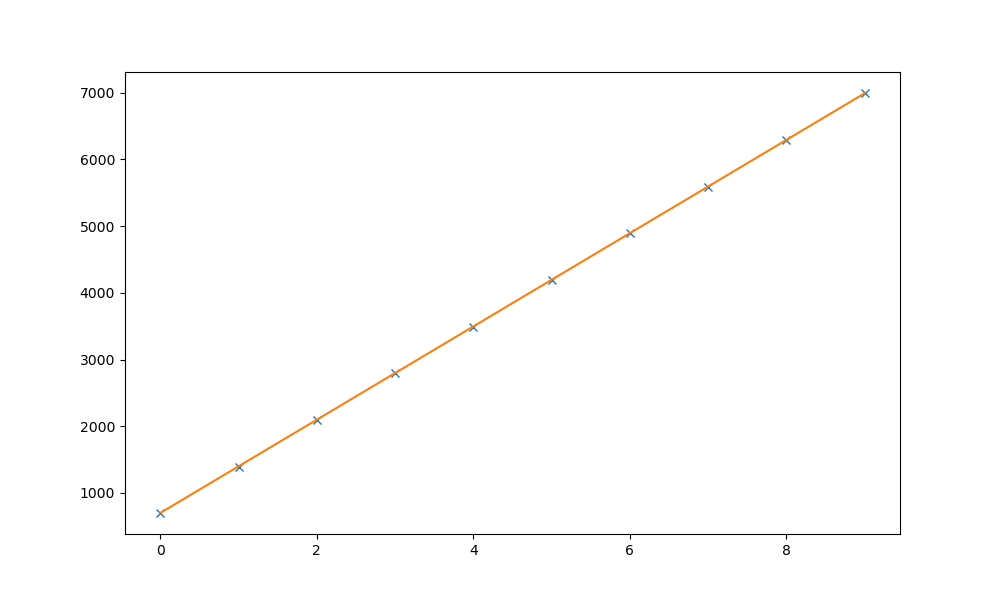

In [ ]:
first_10_peaks = peaks[:10]

plt.figure(figsize=(10, 6))
plt.plot(freqs[first_10_peaks], 'x')

#fit lineare
x = np.arange(len(first_10_peaks))
#y = np.zeros(len(first_10_peaks)+1)
#y[0] = 0
y = freqs[first_10_peaks]

coefficients = np.polyfit(x, y, 1)

plt.plot(x, np.polyval(coefficients, x), label='Fit Lineare')


f0 = coefficients[0]
print(f"F0 stimata: {f0:.2f} Hz")